[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter3_seminar_notebook.ipynb)

# Time Series Analysis — Seminar 3: Unit roots and ARIMA models

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 3; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_3'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- Helpers of Chapter 3 (`adf_test`, `pp_test`, `kpss_test`, `za_test`, `arima_grid`, `gdp_series`, `ro_inflation`) and the seminar functions: `df_by_hand`, `arima_by_hand`, `ar_roots`, `unit_root_set`, `b1_tests`, `b3_gdp`.

In [ ]:
import itertools
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss, zivot_andrews
from statsmodels.tsa.adfvalues import mackinnonp, mackinnoncrit
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.stats.diagnostic import acorr_ljungbox
SEED = 2026
GDP_SA = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
GDP_START = '2000-01-01'
START = '2000-01-01'
BAND_COL = st.IDAred
CASES = {'n': 'no constant', 'c': 'constant', 'ct': 'constant and trend'}


def ro_gdp():
    """Romanian quarterly real GDP (Eurostat), seasonally and calendar adjusted, million EUR (2010 prices)."""
    return read_eurostat(*GDP_SA).rename('gdp')


def ro_hicp():
    """Romanian HICP (Eurostat, monthly, 2015 = 100)."""
    return read_eurostat(*HICP).rename('hicp')


def ro_inflation(start='2005-01-01'):
    """Romanian 12-month HICP inflation in %: 100 (ln P_t - ln P_{t-12})."""
    return (100 * np.log(ro_hicp()).diff(12)).dropna().loc[start:].rename('infl')


def us_gdp():
    """US quarterly real GDP (FRED GDPC1, billions of chained 2017 dollars, seasonally adjusted)."""
    return read_fred('GDPC1').rename('us_gdp')


def quarterly(s):
    """A quarterly series with a PeriodIndex (for statsmodels ARIMA forecasts with dates)."""
    s = s.copy()
    s.index = pd.PeriodIndex(s.index, freq='Q')
    return s


def monthly(s):
    s = s.copy()
    s.index = pd.PeriodIndex(s.index, freq='M')
    return s


def sample_acf(x, nlags=20):
    """Sample ACF rho(1..nlags) with the divisor T."""
    return acf(np.asarray(x, float), nlags=nlags, fft=True)[1:]


def sample_pacf(x, nlags=20):
    return pacf(np.asarray(x, float), nlags=nlags, method='ywm')[1:]


def acf_bars(ax, r, T, color=st.MainBlue, label='sample ACF', band=True):
    """ACF as bars at lags 1..len(r), with the +-1.96/sqrt(T) bands."""
    lags = np.arange(1, len(r) + 1)
    ax.bar(lags, r, width=0.55, color=color, label=label)
    if band:
        b = 1.96 / np.sqrt(T)
        ax.axhline(b, color=BAND_COL, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$')
        ax.axhline(-b, color=BAND_COL, ls='--', lw=0.9, label='_nolegend_')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlim(0.3, len(r) + 0.7)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def years_axis(ax, step=5):
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


def adf_test(x, reg='c', autolag='AIC', maxlag=None):
    """Augmented Dickey-Fuller test: statistic, MacKinnon p-value, number of lags (chosen by AIC up to
    12 (T/100)^(1/4) by default), observations used, 5% critical value."""
    x = np.asarray(pd.Series(x).dropna(), float)
    r = adfuller(x, regression=reg, autolag=autolag, maxlag=maxlag)
    return {'stat': float(r[0]), 'p': float(r[1]), 'lags': int(r[2]), 'nobs': int(r[3]), 'crit5': float(r[4]['5%']),
            'crit1': float(r[4]['1%']), 'crit10': float(r[4]['10%'])}


def pp_test(x, reg='c', lags=None):
    """Phillips-Perron Z_tau test: the Dickey-Fuller regression without lagged differences; the t-statistic is
    corrected with the Newey-West long-run variance of the residuals (Bartlett weights, 12 (T/100)^(1/4) lags).
    Same null hypothesis (unit root) and the same MacKinnon critical values as the ADF test."""
    y = np.asarray(pd.Series(x).dropna(), float)
    dy, ylag = np.diff(y), y[:-1]
    n = len(dy)
    cols = [ylag]
    if reg in ('c', 'ct'):
        cols.append(np.ones(n))
    if reg == 'ct':
        cols.append(np.arange(1, n + 1, dtype=float))
    X = np.column_stack(cols)
    beta, *_ = np.linalg.lstsq(X, dy, rcond=None)
    u = dy - X @ beta
    k = X.shape[1]
    s2 = u @ u / (n - k)
    se = np.sqrt(s2 * np.linalg.inv(X.T @ X)[0, 0])
    t = beta[0] / se
    L = int(np.ceil(12 * (n / 100) ** 0.25)) if lags is None else lags
    g0 = u @ u / n
    lam2 = g0 + 2 * sum((1 - j / (L + 1)) * (u[j:] @ u[:-j]) / n for j in range(1, L + 1))
    z = np.sqrt(g0 / lam2) * t - 0.5 * (lam2 - g0) / np.sqrt(lam2) * n * se / np.sqrt(s2)
    return {'stat': float(z), 'p': float(mackinnonp(z, regression=reg, N=1)), 'lags': L,
            'crit5': float(mackinnoncrit(N=1, regression=reg, nobs=n)[1])}


def kpss_test(x, reg='c'):
    """KPSS test of stationarity (around a constant, reg='c', or a linear trend, reg='ct'); the p-value is
    interpolated from the table of Kwiatkowski et al. (1992) and lies between 0.01 and 0.10."""
    x = np.asarray(pd.Series(x).dropna(), float)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        r = kpss(x, regression=reg, nlags='auto')
    return {'stat': float(r[0]), 'p': float(r[1]), 'lags': int(r[2]), 'crit5': float(r[3]['5%'])}


def za_test(x, reg='c'):
    """Zivot-Andrews test: unit root against stationarity with one break (in the level, reg='c'; in the trend,
    reg='t'; in both, reg='ct') at an unknown date chosen to give the most negative t-statistic."""
    s = pd.Series(x).dropna()
    r = zivot_andrews(np.asarray(s, float), regression=reg, autolag='AIC')
    return {'stat': float(r[0]), 'p': float(r[1]), 'crit5': float(r[2]['5%']), 'lags': int(r[3]),
            'break': str(s.index[int(r[4])])[:10]}


def verdict(adf, kp, alpha=0.05):
    """ADF and KPSS together: 'I(0)', 'I(1)', or 'conflict' (both reject) / 'inconclusive' (neither rejects)."""
    a, k = adf['p'] < alpha, kp['stat'] > kp['crit5']
    return {(True, False): 'I(0)', (False, True): 'I(1)', (True, True): 'conflict', (False, False): 'inconclusive'}[(a, k)]


def df_tau_batch(y, reg='c'):
    """Dickey-Fuller t-statistics (no lagged differences) for many paths at once: y has shape (R, T+1)."""
    y = np.asarray(y, float)
    dy, ylag = np.diff(y, axis=1), y[:, :-1]
    n = dy.shape[1]
    D = {'n': np.zeros((n, 0)), 'c': np.ones((n, 1)), 'ct': np.column_stack([np.ones(n), np.arange(1, n + 1)])}[reg]
    if D.shape[1]:
        P = D @ np.linalg.pinv(D)
        ylag = ylag - ylag @ P.T
        dy = dy - dy @ P.T
    sxx = np.sum(ylag ** 2, axis=1)
    g = np.sum(ylag * dy, axis=1) / sxx
    u = dy - g[:, None] * ylag
    s2 = np.sum(u ** 2, axis=1) / (n - 1 - D.shape[1])
    return g / np.sqrt(s2 / sxx)


def random_walks(R, T, rng, drift=0.0, phi=1.0, sigma=1.0):
    """R paths of y_t = drift + phi y_{t-1} + e_t, y_0 = 0, t = 1..T (returned with y_0: shape (R, T+1))."""
    e = rng.normal(0, sigma, (R, T))
    y = np.zeros((R, T + 1))
    if phi == 1.0:
        y[:, 1:] = np.cumsum(drift + e, axis=1)
    else:
        for t in range(1, T + 1):
            y[:, t] = drift + phi * y[:, t - 1] + e[:, t - 1]
    return y


def ljung_box(x, m=10, df=0):
    """Ljung-Box Q*(m) with chi-square(m - df) p-value (df = number of estimated ARMA coefficients)."""
    t = acorr_ljungbox(np.asarray(pd.Series(x).dropna(), float), lags=[m], model_df=df, return_df=True).iloc[0]
    return {'lb': float(t['lb_stat']), 'lb_p': float(t['lb_pvalue']), 'm': m, 'df': m - df}


def arima_grid(y, d=1, pmax=2, qmax=2, trend='t'):
    """Fit ARIMA(p, d, q) for p <= pmax, q <= qmax (trend 't' = drift when d = 1, 'c' = mean when d = 0, 'n' = none);
    AICc, BIC and whether the optimiser converged."""
    out = {}
    for p, q in itertools.product(range(pmax + 1), range(qmax + 1)):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            m = ARIMA(y, order=(p, d, q), trend=trend).fit()
        out[(p, q)] = {'aicc': float(m.aicc), 'bic': float(m.bic), 'converged': bool(m.mle_retvals.get('converged', True))}
    return out


def best_order(grid):
    ok = {k: v for k, v in grid.items() if v['converged']}
    return min(ok, key=lambda k: ok[k]['aicc'])


def gdp_series(start=GDP_START):
    """100 ln of Romanian real GDP (quarterly, SA), with a quarterly PeriodIndex."""
    return quarterly(100 * np.log(ro_gdp().loc[start:])).rename('gdp')


def gdp_order():
    """The ARIMA(p,1,q) with drift chosen by AICc (p, q <= 2, converged fits only) for 100 ln GDP since 2000."""
    p, q = best_order(arima_grid(gdp_series()))
    return (p, 1, q)


def gdp_fit(order=None):
    order = order or gdp_order()
    y = gdp_series()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return ARIMA(y, order=order, trend='t').fit()


def psi_weights(ar=(), ma=(), d=0, n=30):
    """psi_j (j = 0..n-1) of phi(L)(1 - L)^d y_t = theta(L) e_t: the forecast error of horizon h has variance
    sigma^2 (psi_0^2 + ... + psi_{h-1}^2)."""
    a = np.r_[1, -np.asarray(ar, float)]
    for _ in range(d):
        a = np.convolve(a, [1, -1])
    return ArmaProcess(a, np.r_[1, np.asarray(ma, float)]).impulse_response(n)


def ols_summary(y, x):
    from statsmodels.stats.stattools import durbin_watson
    d = pd.concat([y, x], axis=1).dropna()
    m = sm.OLS(d.iloc[:, 0], sm.add_constant(d.iloc[:, 1])).fit()
    return {'n': int(len(d)), 'b': float(m.params.iloc[1]), 't': float(m.tvalues.iloc[1]), 'p': float(m.pvalues.iloc[1]),
            'r2': float(m.rsquared), 'dw': float(durbin_watson(m.resid))}, m


def df_by_hand(gamma, se, T, reg='c'):
    """Dickey-Fuller statistic tau = gamma/SE, its 5% MacKinnon critical value for T observations, the p-value,
    phi = 1 + gamma, and the (wrong) decision of a one-sided Normal test."""
    tau = gamma / se
    cv = mackinnoncrit(N=1, regression=reg, nobs=T)
    return {'tau': tau, 'crit5': float(cv[1]), 'crit1': float(cv[0]), 'crit10': float(cv[2]),
            'p': float(mackinnonp(tau, regression=reg, N=1)), 'phi': 1 + gamma, 'reject_df': bool(tau < cv[1]),
            'reject_normal': bool(tau < -1.645)}


def arima_by_hand(ar=(), ma=(), d=1, y=(), e_last=0.0, sigma=1.0, H=3):
    """Point forecasts and 95% intervals of phi(L)(1-L)^d y_t = theta(L) e_t (no constant), from the last
    observations y (oldest first) and the last residual e_last, by recursion; psi weights for the variances."""
    a = np.r_[1, -np.asarray(ar, float)]
    for _ in range(d):
        a = np.convolve(a, [1, -1])
    coef = -a[1:]                                   # y_t = sum coef_i y_{t-i} + e_t + sum ma_j e_{t-j}
    hist = list(map(float, y))
    errs = [0.0] * (len(ma) - 1) + [float(e_last)] if ma else []
    f = []
    for h in range(H):
        yt = sum(c * hist[-1 - i] for i, c in enumerate(coef))
        if ma and h == 0:
            yt += sum(m * errs[-1 - j] for j, m in enumerate(ma))
        hist.append(yt)
        f.append(yt)
    psi = psi_weights(ar, ma, d, H)
    var = sigma ** 2 * np.cumsum(psi ** 2)
    return {'f': f, 'psi': [float(v) for v in psi], 'var': [float(v) for v in var],
            'half': [float(1.96 * np.sqrt(v)) for v in var],
            'lo': [float(x - 1.96 * np.sqrt(v)) for x, v in zip(f, var)], 'hi': [float(x + 1.96 * np.sqrt(v)) for x, v in zip(f, var)]}


def ar_roots(coefs):
    """Roots of 1 - a_1 z - ... - a_p z^p for y_t = a_1 y_{t-1} + ... + a_p y_{t-p} + ..."""
    r = np.roots(np.r_[-np.asarray(coefs, float)[::-1], 1.0])
    return sorted(float(np.real(x)) for x in r)


def unit_root_set(x, reg_level='ct'):
    """ADF, PP and KPSS on a level (constant and trend by default) and on its first difference (constant)."""
    x = pd.Series(x).dropna()
    d = x.diff().dropna()
    lv = {'adf': adf_test(x, reg_level), 'pp': pp_test(x, reg_level), 'kpss': kpss_test(x, reg_level)}
    df = {'adf': adf_test(d, 'c'), 'pp': pp_test(d, 'c'), 'kpss': kpss_test(d, 'c')}
    lv['verdict'], df['verdict'] = verdict(lv['adf'], lv['kpss']), verdict(df['adf'], df['kpss'])
    return {'n': int(len(x)), 'first': str(x.index[0])[:10], 'level': lv, 'diff': df}


def b1_tests(name='bet', fname='ch3_sem_b1', save=True):
    """100 ln P_t of an index and its daily returns: the series, ADF/PP/KPSS on both."""
    p = 100 * np.log(load_close(name, start=START if name != 'eurron' else None))
    out = unit_root_set(p, 'ct')
    tt = np.arange(len(p))
    b = np.polyfit(tt, p.values, 1)
    fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.0))
    ax[0].plot(p.index, p, color=st.COL.get(name, st.MainBlue), lw=0.9, label='100 ln P')
    ax[0].plot(p.index, np.polyval(b, tt), color=st.DarkText, ls='--', lw=0.9, label='fitted linear trend')
    ax[0].set_title(f'{name.upper() if name == "bet" else name}: 100 ln P (ADF p = {out["level"]["adf"]["p"]:.2f})')
    r = p.diff().dropna()
    ax[1].plot(r.index, r, color=st.COL.get(name, st.MainBlue), lw=0.5, label='_nolegend_')
    ax[1].set_title(f'Daily log returns, % (ADF = {out["diff"]["adf"]["stat"]:.1f})')
    for a in ax:
        years_axis(a, 5)
    st.fig_legend_bottom(fig, ncol=2, y=-0.01)
    plt.tight_layout()
    if save:
        st.check_no_grey(fig)
        st.save_fig(fname)
    else:
        plt.show()
    resid = p.values - np.polyval(b, tt)
    out['dev_last'] = float(resid[-1])
    out['dev_min'] = float(resid.min())
    out['dev_min_d'] = str(p.index[int(np.argmin(resid))])[:10]
    return out


def b3_gdp(H=8, save=True):
    """Romanian real GDP since 2000: tests on 100 ln Y and its growth, ARIMA(p,1,q) with drift chosen by AICc,
    Ljung-Box on the residuals, forecasts for H quarters with 80% and 95% intervals."""
    y = gdp_series()
    tests = unit_root_set(y, 'ct')
    grid = arima_grid(y)
    p, q = best_order(grid)
    m = ARIMA(y, order=(p, 1, q), trend='t').fit()
    e = m.resid.iloc[1:]
    f = m.get_forecast(H)
    mean, ci95, ci80 = f.predicted_mean, f.conf_int(alpha=0.05), f.conf_int(alpha=0.20)
    fig, ax = plt.subplots(figsize=(9.6, 3.2))
    hist = y.loc['2015Q1':]
    ax.plot(hist.index.to_timestamp(), hist, color=st.DarkText, lw=1.2, label='100 ln real GDP')
    x = mean.index.to_timestamp()
    ax.plot(x, mean, color=st.IDAred, lw=1.4, label=f'ARIMA({p},1,{q}) with drift')
    ax.fill_between(x, ci95.iloc[:, 0], ci95.iloc[:, 1], color=st.IDAred, alpha=0.15, label='95% interval')
    ax.fill_between(x, ci80.iloc[:, 0], ci80.iloc[:, 1], color=st.IDAred, alpha=0.3, label='80% interval')
    ax.set_title(f'Romania: 100 ln real GDP and forecasts for {H} quarters')
    years_axis(ax, 1)
    st.legend_outside_bottom(ax, ncol=4, y=-0.15)
    plt.tight_layout()
    if save:
        st.check_no_grey(fig)
        st.save_fig('ch3_sem_b3')
    else:
        plt.show()
    half = ((ci95.iloc[:, 1] - ci95.iloc[:, 0]) / 2).values
    return {'tests': tests, 'grid': {f'{a}{b}': v for (a, b), v in grid.items()}, 'order': [p, 1, q],
            'params': {k: float(v) for k, v in m.params.items()}, 'se': {k: float(v) for k, v in m.bse.items()},
            'lb8': ljung_box(e, 8, p + q), 'last': float(y.iloc[-1]), 'last_q': str(y.index[-1]),
            'f1': float(mean.iloc[0]), 'f4': float(mean.iloc[3]), 'f8': float(mean.iloc[H - 1]), 'last_fq': str(mean.index[-1]),
            'half2': float(half[1]), 'half8': float(half[H - 1]), 'half1': float(half[0]),
            'lo8': float(ci95.iloc[H - 1, 0]), 'hi8': float(ci95.iloc[H - 1, 1]), 'growth8': float(mean.iloc[H - 1] - y.iloc[-1])}

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: a Dickey–Fuller statistic

**Context.** A monthly interest rate, $T = 120$: OLS gives $\Delta y_t = 0.42 - 0.061\,y_{t-1}$, with $\mathrm{SE}(\hat\gamma) = 0.025$.

1. Compute $\tau$ and $\hat\phi$.
2. Compare $\tau$ with the 5% Dickey–Fuller value for a regression with a constant, and decide.
3. Say what a standard one-sided $t$-test would have concluded.
4. Explain why a constant (and no trend) is the right choice for an interest rate.

**Report:** two numbers, a decision and two sentences.

In [7]:
# Solution
df_by_hand(-0.061, 0.025, 120, 'c')

{'tau': -2.44,
 'crit5': -2.8859430324074076,
 'crit1': -3.486055829282407,
 'crit10': -2.5797850694444446,
 'p': 0.1307634143441469,
 'phi': 0.9390000000000001,
 'reject_df': False,
 'reject_normal': True}

**Interpretation of the result.** $\tau = -2.44$ is above the Dickey–Fuller value (about $-2.89$) but below $-1.645$: the Dickey–Fuller table does not reject the unit root, a Normal table would wrongly reject it.

## A2 [Proposed]: choosing the deterministic terms

**Context.** The log of a price index ($T = 200$) rises steadily. ADF: $\tau = 1.85$ (no constant), $-1.21$ (constant), $-3.62$ (constant and trend); KPSS with trend: 0.09. Model: A1.

1. Say which specification fits the data, and why.
2. Decide at 5% in each specification (critical values: `mackinnoncrit(N=1, regression=..., nobs=200)`).
3. Combine the chosen ADF result with KPSS (5% value 0.146).
4. Say how you would model the series.

**Report:** three decisions, a verdict and one sentence.

In [ ]:
# Your code here


## A3 [Solved]: ARIMA(1,1,0) forecasts

**Context.** $\Delta y_t = 0.6\,\Delta y_{t-1} + \varepsilon_t$, $\sigma = 2$; $y_{T-1} = 103$, $y_T = 108$.

1. Compute $\hat y_{T+1}$, $\hat y_{T+2}$ and $\hat y_{T+3}$.
2. Compute $\psi_1$ and $\psi_2$, and the forecast error variances for $h = 1, 2, 3$.
3. Give the 95% intervals.

**Report:** three forecasts and three intervals.

In [9]:
# Solution
arima_by_hand(ar=(0.6,), d=1, y=(103.0, 108.0), sigma=2.0, H=3)

{'f': [np.float64(111.00000000000001),
  np.float64(112.80000000000003),
  np.float64(113.88000000000004)],
 'psi': [1.0, 1.6, 1.9600000000000004],
 'var': [4.0, 14.240000000000002, 29.606400000000008],
 'half': [3.92, 7.396241207532378, 10.664705633068362],
 'lo': [107.08000000000001, 105.40375879246764, 103.21529436693167],
 'hi': [114.92000000000002, 120.19624120753241, 124.5447056330684]}

**Interpretation of the result.** The forecasts rise by 3, 1.8 and 1.08: the momentum fades. The half-width grows from 3.92 to 10.66 in three steps, faster than $\sqrt{3}$, because $\psi_j$ grows towards $1/(1 - \phi) = 2.5$.

## A4 [Proposed]: ARIMA(0,1,1) and exponential smoothing

**Context.** $\Delta y_t = \varepsilon_t - 0.6\,\varepsilon_{t-1}$, $\sigma = 1$; $y_T = 50$, $\hat\varepsilon_T = 1.5$. Model: A3.

1. Compute $\hat y_{T+1}$ and $\hat y_{T+h}$ for $h \ge 2$.
2. Compute the forecast error variances for $h = 1$, $2$ and $5$, and the 95% intervals.
3. Show that the forecast equals simple exponential smoothing (Chapter 0) and give $\alpha$.

**Report:** two forecasts, three intervals and $\alpha$.

In [ ]:
# Your code here


## A5 [Solved]: the order of integration of an equation

**Context.** $y_t = 1.5\,y_{t-1} - 0.5\,y_{t-2} + \varepsilon_t + 0.4\,\varepsilon_{t-1}$.

1. Write the AR polynomial $\phi(z)$ and find its roots.
2. Say whether $y_t$ is stationary, and give $d$.
3. Write the model as ARIMA$(p,d,q)$ for $\Delta y_t$.

**Report:** two roots, $d$ and the ARIMA equation.

In [11]:
# Solution
ar_roots([1.5, -0.5])

[1.0, 2.0]

**Interpretation of the result.** Roots 1 and 2: one unit root, so $d = 1$ and $\Delta y_t = 0.5\,\Delta y_{t-1} + \varepsilon_t + 0.4\,\varepsilon_{t-1}$, an ARIMA(1,1,1).

## A6 [Proposed]: integrated or over-differenced?

**Context.** (a) $y_t = 1.8\,y_{t-1} - 0.8\,y_{t-2} + \varepsilon_t$; (b) $\Delta y_t = \varepsilon_t - \varepsilon_{t-1}$. Model: A5.

1. For (a), factor $\phi(z)$, give $d$ and write the ARIMA model.
2. For (b), find the MA root and say what $y_t$ really is.
3. Compute $\rho(1)$ of $\Delta y_t$ in (b) and say how you would detect this case in data.

**Report:** two orders of integration and two sentences.

In [ ]:
# Your code here


# Part B: real data and interpretation

## B1 [Solved]: is the BET log price a random walk?

**Question.** Does the BET log price have a unit root, and are its daily returns stationary?

1. Plot $p_t = 100\ln P_t$ with a fitted linear trend, and plot $r_t = \Delta p_t$.
2. Run ADF (lags by AIC), PP and KPSS on $p_t$ with constant and trend.
3. Run the same tests on $r_t$ with a constant.
4. Interpretation: if the BET is far below its fitted trend line, should you expect it to return to the line?

**Report:** a table of six statistics, two verdicts and two sentences.

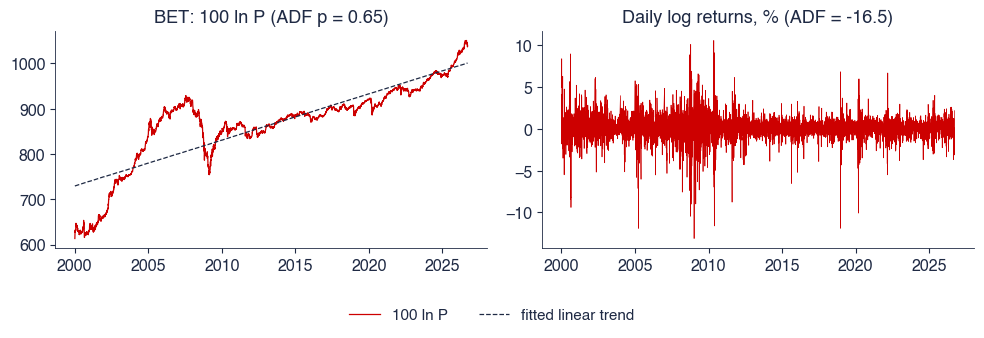

,ADF,ADF p,lags,PP,KPSS,verdict
level,-1.903364,0.652924,19,-2.348332,1.142908,I(1)
diff,-16.503303,0.0,18,-74.550721,0.359518,I(0)


In [13]:
# Solution
b1 = b1_tests('bet', save=False)
pd.DataFrame({part: {'ADF': b1[part]['adf']['stat'], 'ADF p': b1[part]['adf']['p'], 'lags': b1[part]['adf']['lags'], 'PP': b1[part]['pp']['stat'], 'KPSS': b1[part]['kpss']['stat'], 'verdict': b1[part]['verdict']} for part in ['level', 'diff']}).T

**Interpretation of the result.** The log price has a unit root and the returns are stationary. With a unit root the trend line does not attract the series: a distance from the line carries no forecast of a return to it.

## B2 [Proposed]: the S&P 500 and EUR/RON

**Question.** Do the S&P 500 and the EUR/RON rate give the same verdicts as the BET? Model: B1.

1. Repeat steps 2 and 3 of B1 for both series (`unit_root_set(100 * np.log(load_close('sp500', start=START)))`, and the same for `'eurron'` without `start`).
2. Compare the ADF and PP statistics of the returns, and explain why PP is much more negative.
3. Interpretation: the EUR/RON rate is managed by the central bank; does the test result say that it is a random walk?

**Report:** a table (two series, two rows each) and two sentences.

In [ ]:
# Your code here


## B3 [Solved]: an ARIMA model for Romanian GDP

**Question.** Which ARIMA model describes Romanian real GDP, and how uncertain is a two-year forecast?

1. Choose $d$ with ADF and KPSS on $y_t = 100\ln Y_t$ (constant and trend) and on $\Delta y_t$ (constant).
2. Fit ARIMA$(p,1,q)$ with drift for $p, q \le 2$ and choose the model with the lowest AICc.
3. Check the residuals with Ljung–Box $Q^*(8)$.
4. Forecast 8 quarters with 80% and 95% intervals.
5. Interpretation: why is the 95% interval after 8 quarters about twice as wide as after 2 quarters?

**Report:** the tests, the AICc of six models, the chosen model, $Q^*(8)$, the chart and one sentence.

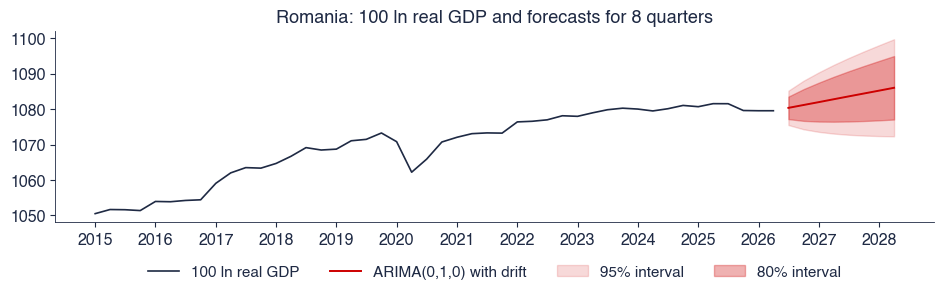

verdicts: I(1) I(0)
AICc: {'00': 491.9, '01': 493.7, '02': 493.6, '10': 493.8, '11': 494.9, '12': 495.8, '20': 493.7, '21': 495.7, '22': 495.4}
model: [0, 1, 0] {'x1': 0.8092105217056731, 'sigma2': 6.09661381016646} Q*(8): {'lb': 7.282740060049913, 'lb_p': 0.5064570581675445, 'm': 8, 'df': 8}
half-widths after 2 and 8 quarters: 6.84 13.69


In [15]:
# Solution
b3 = b3_gdp(save=False)
print('verdicts:', b3['tests']['level']['verdict'], b3['tests']['diff']['verdict'])
print('AICc:', {k: round(v['aicc'], 1) for k, v in b3['grid'].items()})
print('model:', b3['order'], b3['params'], 'Q*(8):', b3['lb8'])
print('half-widths after 2 and 8 quarters:', round(b3['half2'], 2), round(b3['half8'], 2))

**Interpretation of the result.** The chosen model is a random walk with drift, whose error variance is $h\sigma^2$: the interval grows like $\sqrt{h}$, and $\sqrt{8/2} = 2$.

## B4 [Proposed]: Romanian inflation, $d = 0$ or $d = 1$?

**Question.** Is Romanian 12-month inflation stationary, and how much does the answer change the forecast? Model: B3.

1. Run ADF, PP and KPSS on $\pi_t$ (`ro_inflation()`) and on $\Delta\pi_t$, with a constant.
2. Find the best ARIMA$(p,0,q)$ with a mean and the best ARIMA$(p,1,q)$ by AICc, with $p \le 3$, $q \le 2$.
3. Forecast 12 months with both models, with 95% intervals, and run Ljung–Box $Q^*(24)$ on their residuals.
4. Interpretation: why do the two models give similar point forecasts but different intervals?

**Report:** a table of tests, two models, two forecasts with intervals, two Ljung–Box tests and two sentences.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: a break or a unit root?

**Question.** Do Romanian inflation and GDP have a unit root, or are they stationary around a mean or a trend that shifted once? Models: B1, B3.

1. Run the Zivot–Andrews test with a break in the level, then in the level and the trend, on both series.
2. Compare each statistic with its 5% critical value and report the break dates.
3. Match the dates with events (inflation targeting since 2005, the 2008–2009 crisis, the 2022 energy shock).
4. Interpretation: why should a break date found by a test be checked against history before it is believed?

**Report:** a table of four statistics with dates, the chart and a plan for a project.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant analysed Romanian GDP and prices. It answered:

- (a) the ADF p-value for log GDP is above 0.05, so GDP is proved to have a unit root;
- (b) the KPSS statistic for log GDP is above 0.146, so KPSS rejects the unit root;
- (c) regressing log HICP on the log S&P 500 gives a huge t-statistic: US stocks drive Romanian prices;
- (d) GDP growth is stationary, so differencing it once more will make the ARIMA model even better;
- (e) a random-walk forecast has the same 95% interval width at every horizon;
- (f) the 5% Dickey–Fuller critical value with a constant is more negative than $-1.645$, because the Dickey–Fuller distribution is shifted to the left.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** six verdicts with one line of justification each.

In [ ]:
# Your code here
